# IMPORT LIBRARY

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv("/content/poverty_classification.csv", sep=";")

In [33]:
df.head()

,Provinsi,Kab/Kota,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
0,ACEH,Simeulue,"18,98","9,48",7148.0,"66,41","65,28","71,56","87,45","5,71","71,15",1648096.0,0.0
1,ACEH,Aceh Singkil,"20,36","8,68",8776.0,"69,22","67,43","69,56","78,58","8,36","62,85",1780419.0,1.0
2,ACEH,Aceh Selatan,"13,18","8,88",8180.0,"67,44","64,4","62,55","79,65","6,46","60,85",4345784.0,0.0
3,ACEH,Aceh Tenggara,"13,41","9,67",8030.0,"69,44","68,22","62,71","86,71","6,43","69,62",3487157.0,0.0
4,ACEH,Aceh Timur,"14,45","8,21",8577.0,"67,83","68,74","66,75","83,16","7,13","59,48",8433526.0,0.0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    object 
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    object 
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    object 
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    object 
 7  

In [35]:
df.shape

(999, 13)

In [36]:
df.columns

Index(['Provinsi', 'Kab/Kota',
       'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
       'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
       'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
       'Indeks Pembangunan Manusia', 'Umur Harapan Hidup (Tahun)',
       'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak',
       'Persentase rumah tangga yang memiliki akses terhadap air minum layak',
       'Tingkat Pengangguran Terbuka', 'Tingkat Partisipasi Angkatan Kerja',
       'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)',
       'Klasifikasi Kemiskinan'],
      dtype='object')

In [37]:
df.describe()

,Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
count,514.000000,5.140000e+02,514.000000
mean,10324.787938,2.196408e+07,0.120623
std,2717.144186,4.790492e+07,0.326005
min,3976.000000,1.474850e+05,0.000000
25%,8574.000000,3.654292e+06,0.000000
50%,10196.500000,8.814926e+06,0.000000
75%,11719.000000,1.973510e+07,0.000000
max,23888.000000,4.600810e+08,1.000000


In [38]:
df.isnull().sum()

,0
Provinsi,485
Kab/Kota,485
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),485
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),485
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),485
Indeks Pembangunan Manusia,485
Umur Harapan Hidup (Tahun),485
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,485
Persentase rumah tangga yang memiliki akses terhadap air minum layak,485
Tingkat Pengangguran Terbuka,485


In [39]:
df.duplicated().sum()

np.int64(484)

In [40]:
df.dtypes

,0
Provinsi,object
Kab/Kota,object
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),object
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),object
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),float64
Indeks Pembangunan Manusia,object
Umur Harapan Hidup (Tahun),object
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,object
Persentase rumah tangga yang memiliki akses terhadap air minum layak,object
Tingkat Pengangguran Terbuka,object


# DATA CLEANING

In [41]:
df= df.dropna()

In [42]:
df.shape

(514, 13)

In [43]:
df.isnull().sum()

,0
Provinsi,0
Kab/Kota,0
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),0
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),0
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),0
Indeks Pembangunan Manusia,0
Umur Harapan Hidup (Tahun),0
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,0
Persentase rumah tangga yang memiliki akses terhadap air minum layak,0
Tingkat Pengangguran Terbuka,0


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
numeric_columns = [
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Indeks Pembangunan Manusia',
    'Umur Harapan Hidup (Tahun)',
    'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak',
    'Persentase rumah tangga yang memiliki akses terhadap air minum layak',
    'Tingkat Pengangguran Terbuka',
    'Tingkat Partisipasi Angkatan Kerja'
]

In [46]:
for col in numeric_columns:
    df[col] = df[col].str.replace(',', '.', regex=False)
    df[col] = df[col].astype(float)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 513
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    float64
 7   Pers

In [48]:
df.describe()

,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,5.140000e+02,514.000000
mean,12.273152,8.436615,10324.787938,69.926770,69.656809,77.202237,85.136615,5.059494,69.464455,2.196408e+07,0.120623
std,7.458703,1.630842,2717.144186,6.497033,3.447464,18.583555,15.701658,2.636970,6.396405,4.790492e+07,0.326005
min,2.380000,1.420000,3976.000000,32.840000,55.430000,0.000000,0.000000,0.000000,56.390000,1.474850e+05,0.000000
25%,7.150000,7.510000,8574.000000,66.642500,67.387500,70.217500,79.042500,3.180000,65.070000,3.654292e+06,0.000000
50%,10.455000,8.305000,10196.500000,69.610000,69.975000,81.800000,89.795000,4.565000,68.955000,8.814926e+06,0.000000
75%,14.887500,9.337500,11719.000000,73.112500,72.042500,89.882500,96.400000,6.530000,72.342500,1.973510e+07,0.000000
max,41.660000,12.830000,23888.000000,87.180000,77.730000,99.970000,100.000000,13.370000,97.930000,4.600810e+08,1.000000


In [49]:
df.to_csv("poverty_clean.csv", index=False)

In [60]:
df.columns

Index(['Provinsi', 'Kab/Kota',
       'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
       'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
       'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
       'Indeks Pembangunan Manusia', 'Umur Harapan Hidup (Tahun)',
       'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak',
       'Persentase rumah tangga yang memiliki akses terhadap air minum layak',
       'Tingkat Pengangguran Terbuka', 'Tingkat Partisipasi Angkatan Kerja',
       'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)',
       'Klasifikasi Kemiskinan'],
      dtype='object')

# EDA

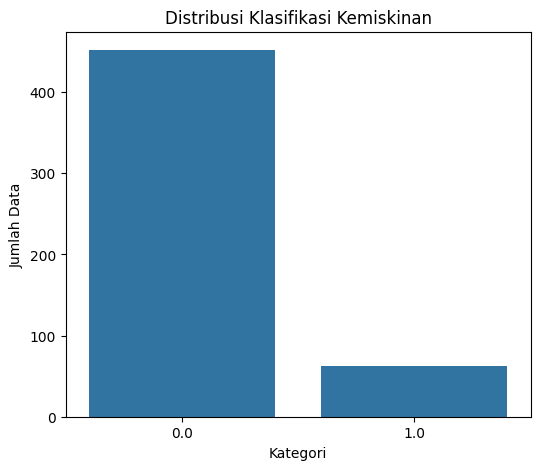

In [51]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Klasifikasi Kemiskinan'
)

plt.title("Distribusi Klasifikasi Kemiskinan")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")

plt.show()

In [52]:
df['Klasifikasi Kemiskinan'].value_counts()

,count
Klasifikasi Kemiskinan,
0.0,452
1.0,62


In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),514.0,1.227315e+01,7.458703e+00,2.38,7.150000e+00,10.455,1.488750e+01,4.166000e+01
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),514.0,8.436615e+00,1.630842e+00,1.42,7.510000e+00,8.305,9.337500e+00,1.283000e+01
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),514.0,1.032479e+04,2.717144e+03,3976.00,8.574000e+03,10196.500,1.171900e+04,2.388800e+04
Indeks Pembangunan Manusia,514.0,6.992677e+01,6.497033e+00,32.84,6.664250e+01,69.610,7.311250e+01,8.718000e+01
Umur Harapan Hidup (Tahun),514.0,6.965681e+01,3.447464e+00,55.43,6.738750e+01,69.975,7.204250e+01,7.773000e+01
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,514.0,7.720224e+01,1.858355e+01,0.00,7.021750e+01,81.800,8.988250e+01,9.997000e+01
Persentase rumah tangga yang memiliki akses terhadap air minum layak,514.0,8.513661e+01,1.570166e+01,0.00,7.904250e+01,89.795,9.640000e+01,1.000000e+02
Tingkat Pengangguran Terbuka,514.0,5.059494e+00,2.636970e+00,0.00,3.180000e+00,4.565,6.530000e+00,1.337000e+01
Tingkat Partisipasi Angkatan Kerja,514.0,6.946446e+01,6.396405e+00,56.39,6.507000e+01,68.955,7.234250e+01,9.793000e+01
PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),514.0,2.196408e+07,4.790492e+07,147485.00,3.654292e+06,8814925.500,1.973510e+07,4.600810e+08


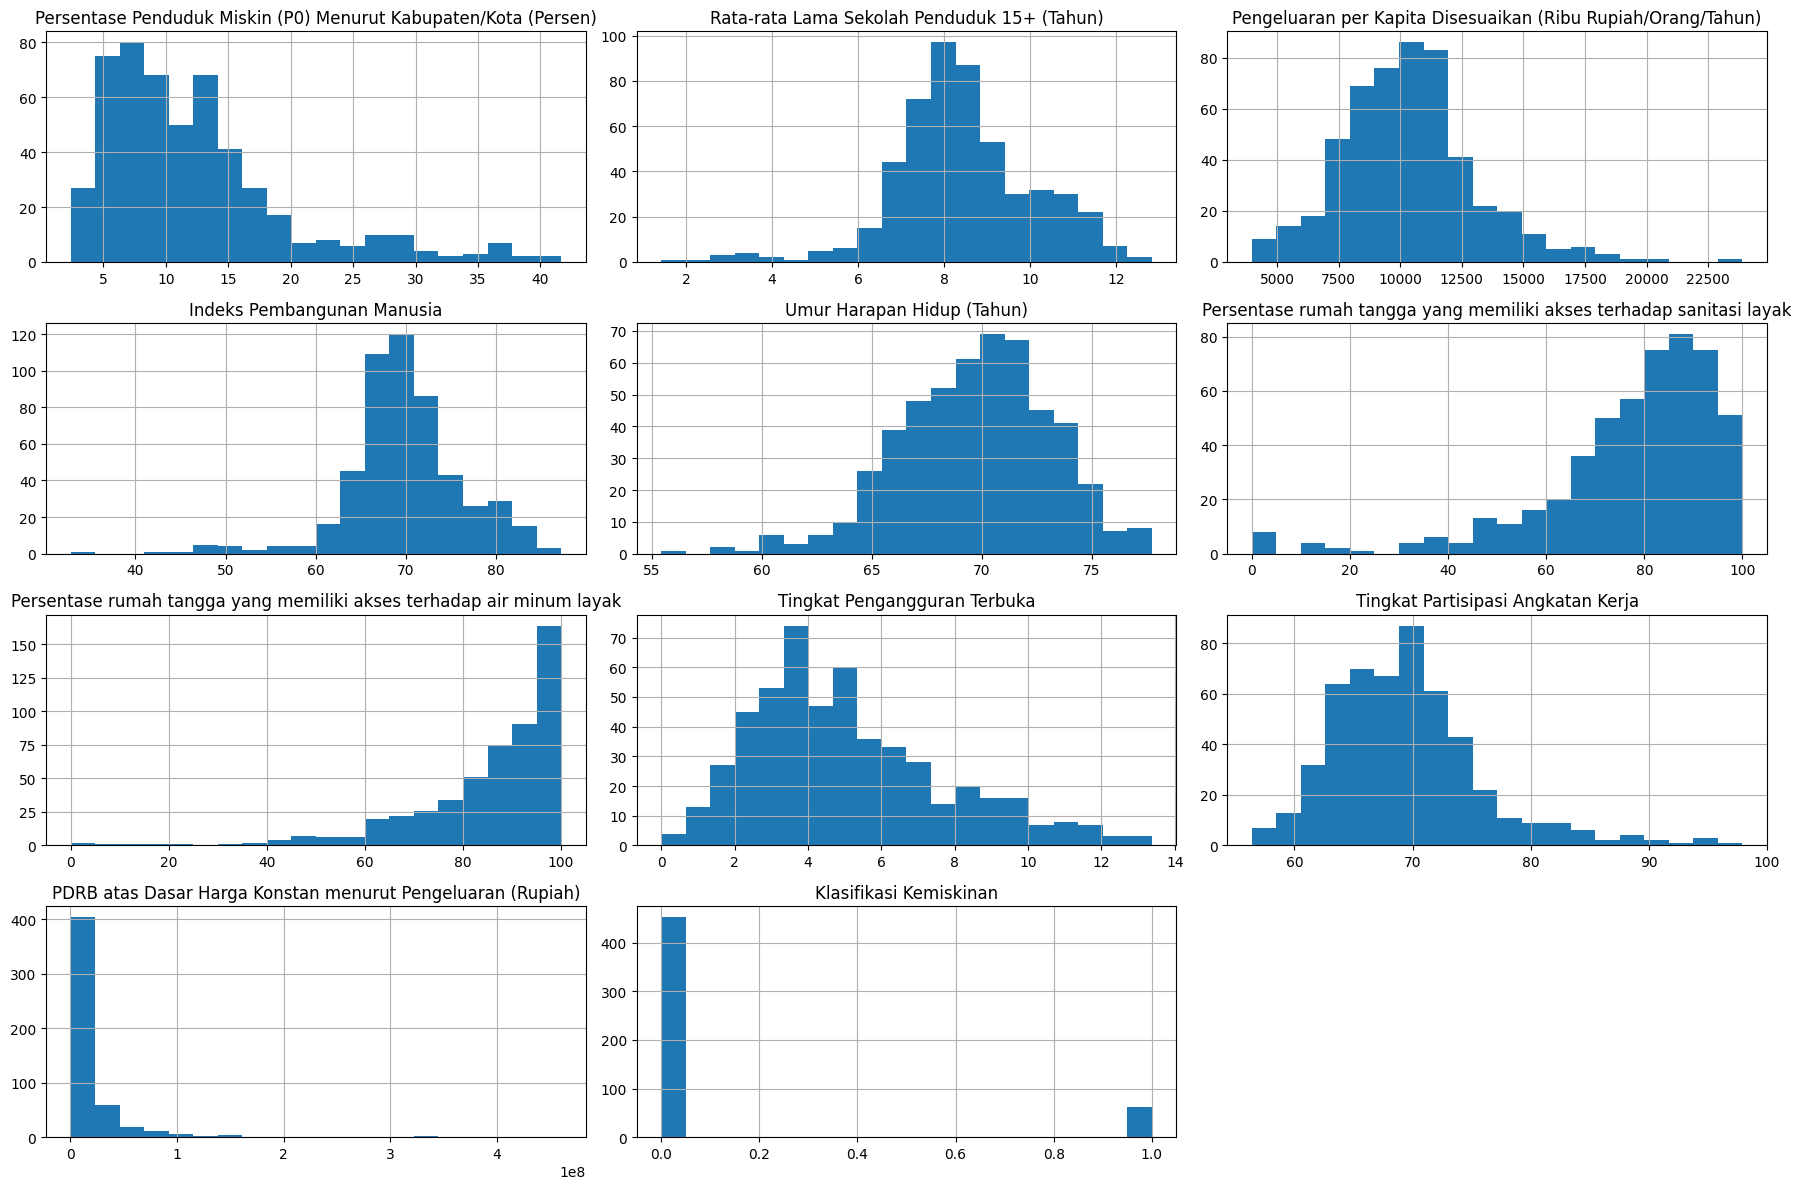

In [63]:
df.hist(figsize=(18,12), bins=20)

plt.tight_layout()

plt.show()

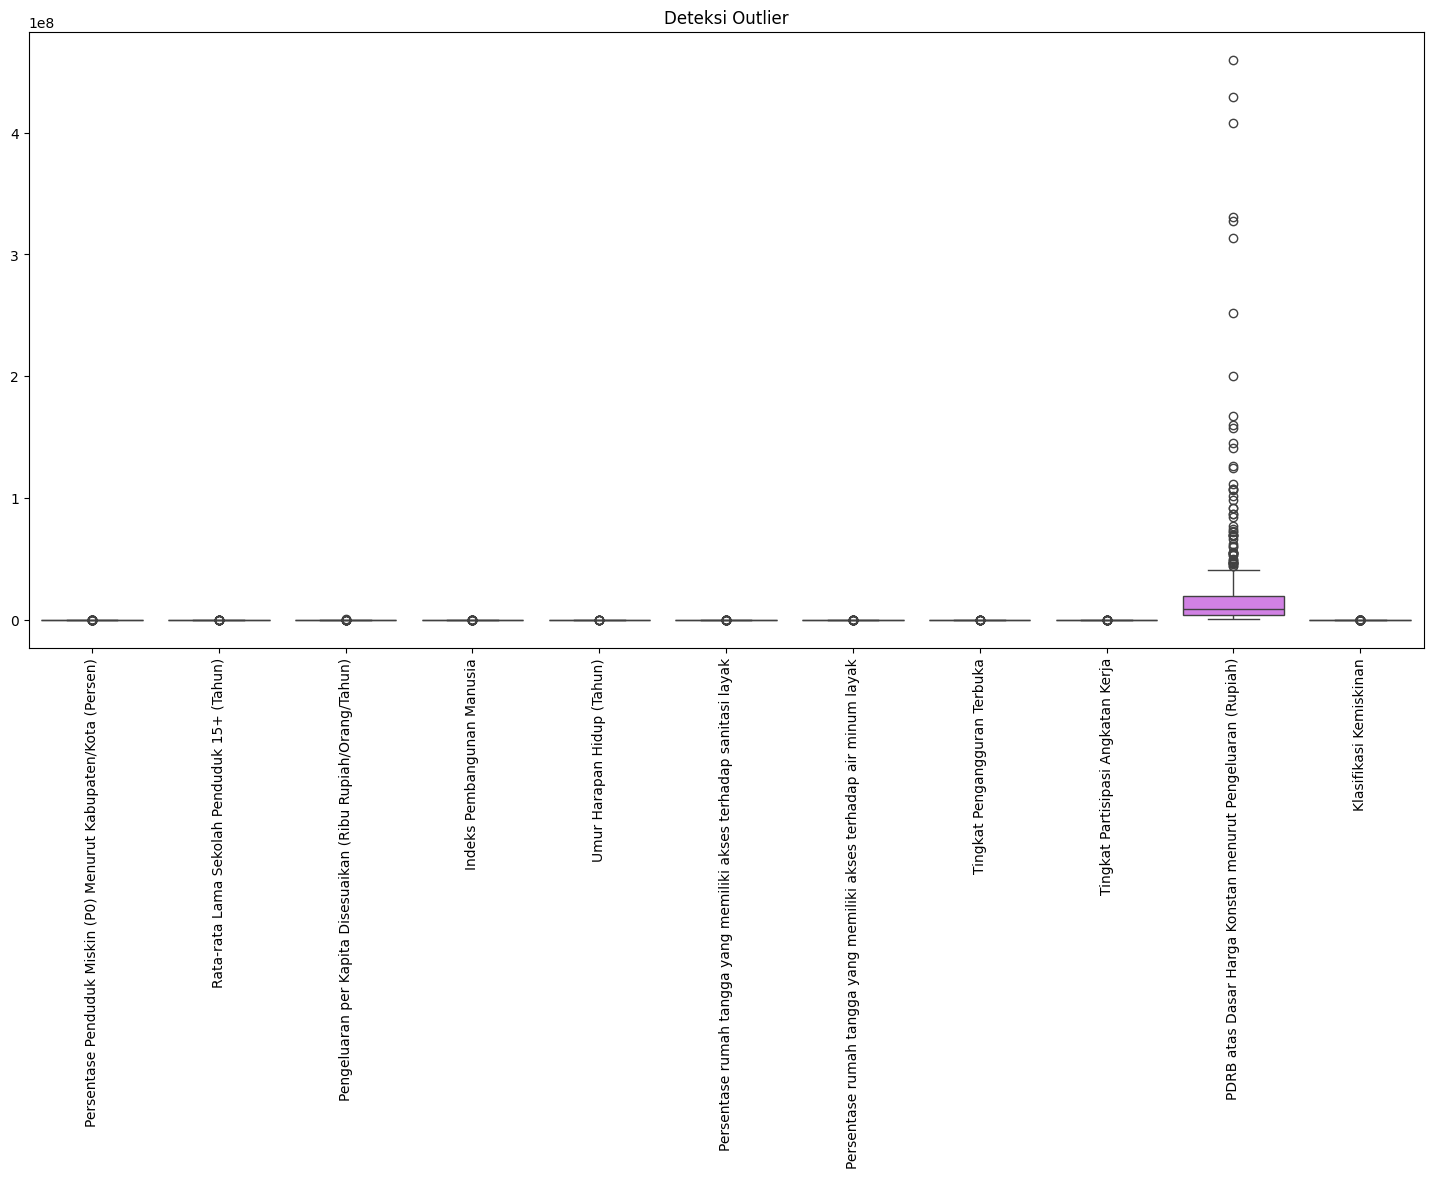

In [54]:
plt.figure(figsize=(18,8))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Deteksi Outlier")

plt.show()

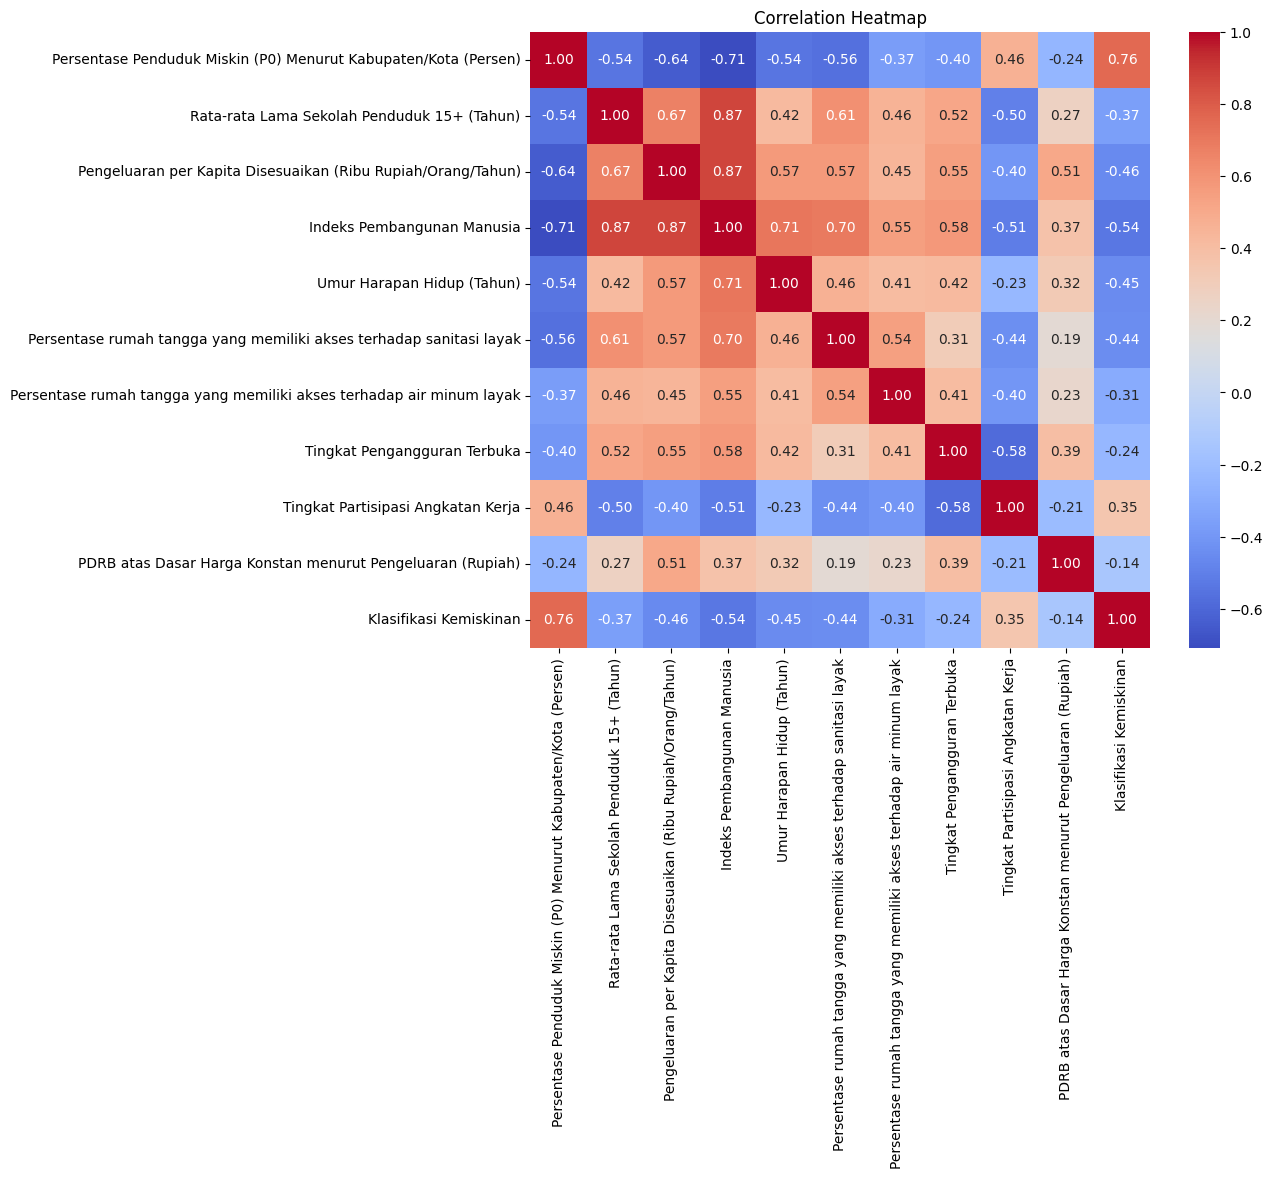

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")

plt.show()

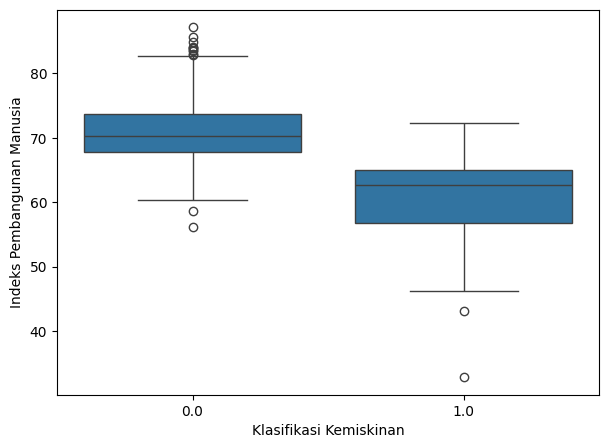

In [56]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Klasifikasi Kemiskinan',
    y='Indeks Pembangunan Manusia'
)

plt.show()

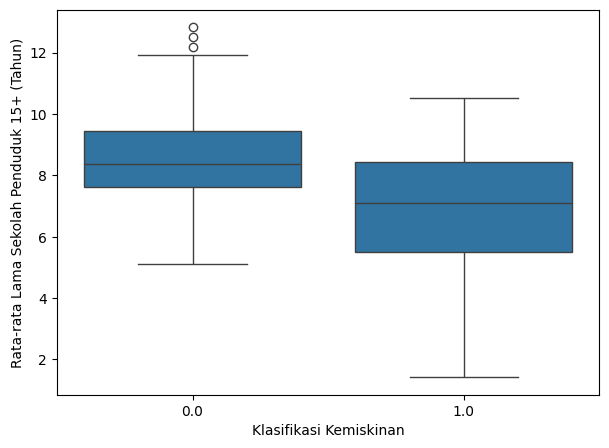

In [57]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Klasifikasi Kemiskinan',
    y='Rata-rata Lama Sekolah Penduduk 15+ (Tahun)'
)

plt.show()

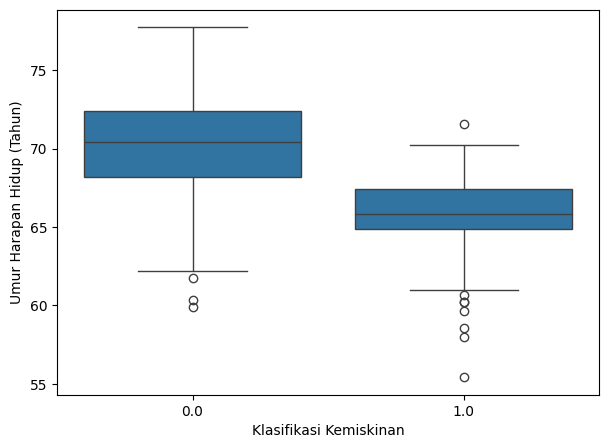

In [58]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Klasifikasi Kemiskinan',
    y='Umur Harapan Hidup (Tahun)'
)

plt.show()

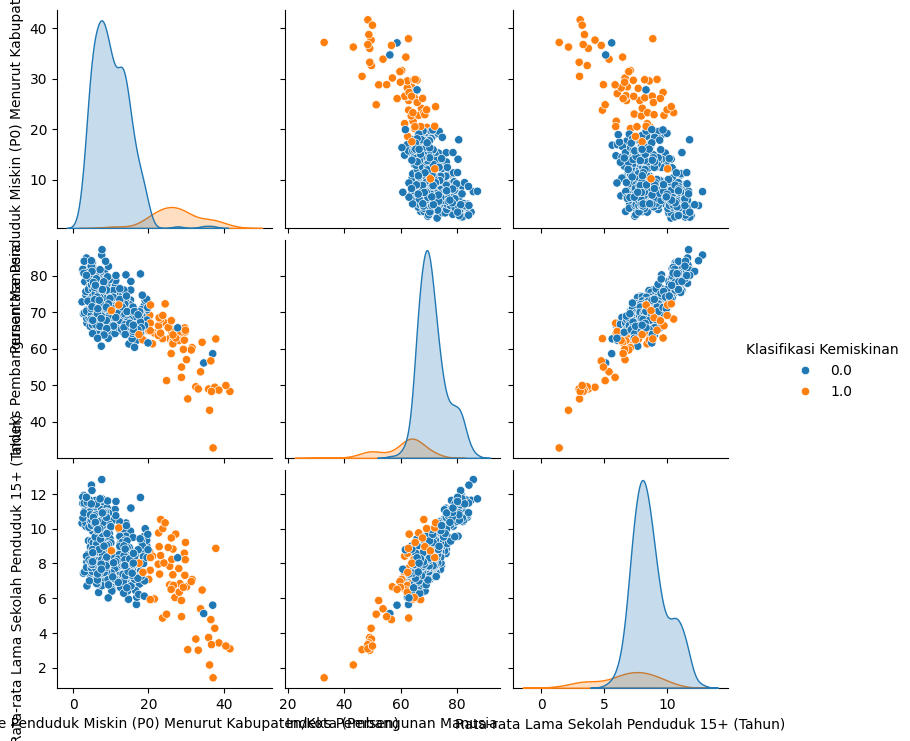

In [59]:
selected_features = [
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Indeks Pembangunan Manusia',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Klasifikasi Kemiskinan'
]

sns.pairplot(df[selected_features], hue='Klasifikasi Kemiskinan')
plt.show()

# PREPOCESSING

In [64]:
# Memisahkan fitur dan target

X = df.drop(columns=[
    'Provinsi',
    'Kab/Kota',
    'Klasifikasi Kemiskinan'
])

y = df['Klasifikasi Kemiskinan']

In [65]:
print("Jumlah fitur :", X.shape[1])
print("Jumlah data :", X.shape[0])

Jumlah fitur : 10
Jumlah data : 514


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (411, 10)
Testing : (103, 10)


In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
X_train_scaled[:5]

array([[ 0.15167797,  0.35838394, -0.88894403, -0.6460245 , -1.62176035,
         0.17954458, -0.0976288 , -0.28188449, -1.04763502, -0.32920473],
       [-1.33233998,  1.34921804,  2.62010432,  1.86678054,  1.63918966,
         1.20752107,  0.97889441,  0.75318127,  0.46970507,  0.16014773],
       [-0.78093881,  0.07528848,  0.36983007,  0.28627168,  0.56009015,
         0.28892694, -0.98581001,  0.01330093,  0.55275948, -0.27818493],
       [-1.22478271,  1.17074482,  0.04370337,  0.90466343,  0.76112787,
        -0.18288652,  0.354392  , -0.75341445, -0.744167  , -0.33859195],
       [-0.23498359,  0.08759698,  0.43917885,  0.95017957,  2.33986522,
         0.97841673,  0.88967978,  0.35448927,  0.57032868,  0.11874999]])

In [70]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (411, 10)
Testing Data : (103, 10)


# LOGISTIC REGRESSION

In [71]:
from sklearn.linear_model import LogisticRegression

# Membuat model
lr_model = LogisticRegression(random_state=42)

# Melatih model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [72]:
# Prediksi data testing
y_pred_lr = lr_model.predict(X_test_scaled)

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.970873786407767
Precision: 0.8461538461538461
Recall   : 0.9166666666666666
F1 Score : 0.88


In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98        91
         1.0       0.85      0.92      0.88        12

    accuracy                           0.97       103
   macro avg       0.92      0.95      0.93       103
weighted avg       0.97      0.97      0.97       103



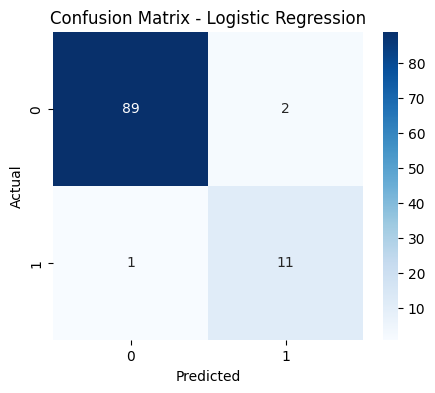

In [75]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [76]:
lr_result = pd.DataFrame({
    'Model':['Logistic Regression'],
    'Accuracy':[accuracy],
    'Precision':[precision],
    'Recall':[recall],
    'F1-Score':[f1]
})

lr_result

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.970874,0.846154,0.916667,0.88


# DECISION TREE

In [77]:
from sklearn.tree import DecisionTreeClassifier

In [78]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [79]:
y_pred_dt = dt_model.predict(X_test)

In [80]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.9902912621359223
Precision: 0.9230769230769231
Recall   : 1.0
F1 Score : 0.96


In [81]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99        91
         1.0       0.92      1.00      0.96        12

    accuracy                           0.99       103
   macro avg       0.96      0.99      0.98       103
weighted avg       0.99      0.99      0.99       103



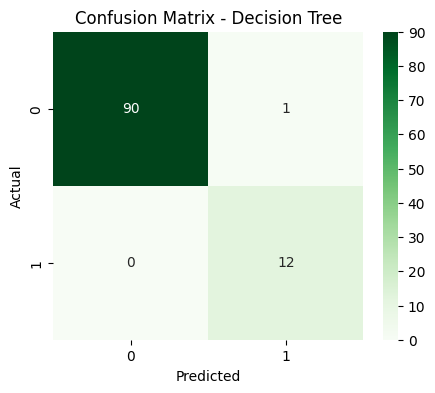

In [82]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [83]:
dt_result = pd.DataFrame({
    'Model':['Decision Tree'],
    'Accuracy':[accuracy_dt],
    'Precision':[precision_dt],
    'Recall':[recall_dt],
    'F1-Score':[f1_dt]
})

dt_result

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.990291,0.923077,1.0,0.96


# GAUSSIAN NAIVE BAYES

In [84]:
from sklearn.naive_bayes import GaussianNB

In [85]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [86]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [87]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Accuracy : 0.9611650485436893
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571


In [88]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        91
         1.0       0.75      1.00      0.86        12

    accuracy                           0.96       103
   macro avg       0.88      0.98      0.92       103
weighted avg       0.97      0.96      0.96       103



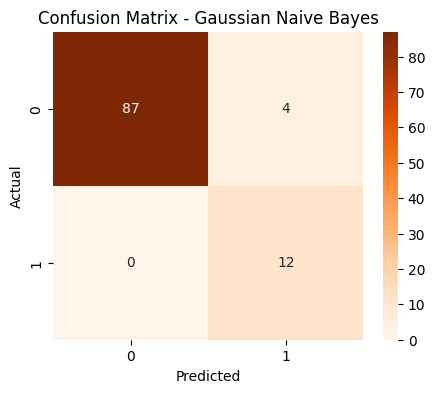

In [89]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

In [90]:
nb_result = pd.DataFrame({
    'Model':['Gaussian Naive Bayes'],
    'Accuracy':[accuracy_nb],
    'Precision':[precision_nb],
    'Recall':[recall_nb],
    'F1-Score':[f1_nb]
})

nb_result

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian Naive Bayes,0.961165,0.75,1.0,0.857143


# PERBANDINGAN MODEL

In [91]:
hasil = pd.concat(
    [lr_result, dt_result, nb_result],
    ignore_index=True
)

hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.970874,0.846154,0.916667,0.880000
1,Decision Tree,0.990291,0.923077,1.000000,0.960000
2,Gaussian Naive Bayes,0.961165,0.750000,1.000000,0.857143


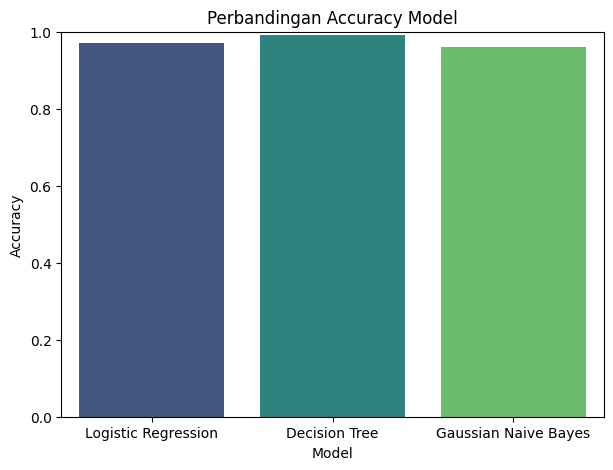

In [92]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=hasil,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.ylim(0,1)
plt.title("Perbandingan Accuracy Model")

plt.show()

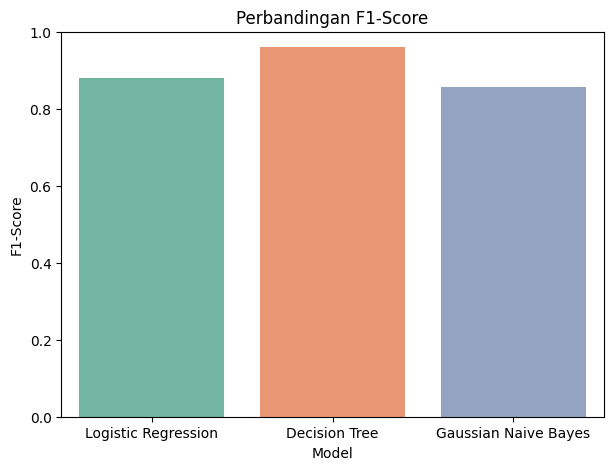

In [93]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=hasil,
    x='Model',
    y='F1-Score',
    palette='Set2'
)

plt.ylim(0,1)
plt.title("Perbandingan F1-Score")

plt.show()

In [94]:
hasil.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.990291,0.923077,1.000000,0.960000
0,Logistic Regression,0.970874,0.846154,0.916667,0.880000
2,Gaussian Naive Bayes,0.961165,0.750000,1.000000,0.857143
